# **Linear Regression from Scratch with more features**

### 1. Import the Essential libraries

In [13]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
import matplotlib.pyplot as plt




In [14]:
data = pd.read_csv("data2.csv")

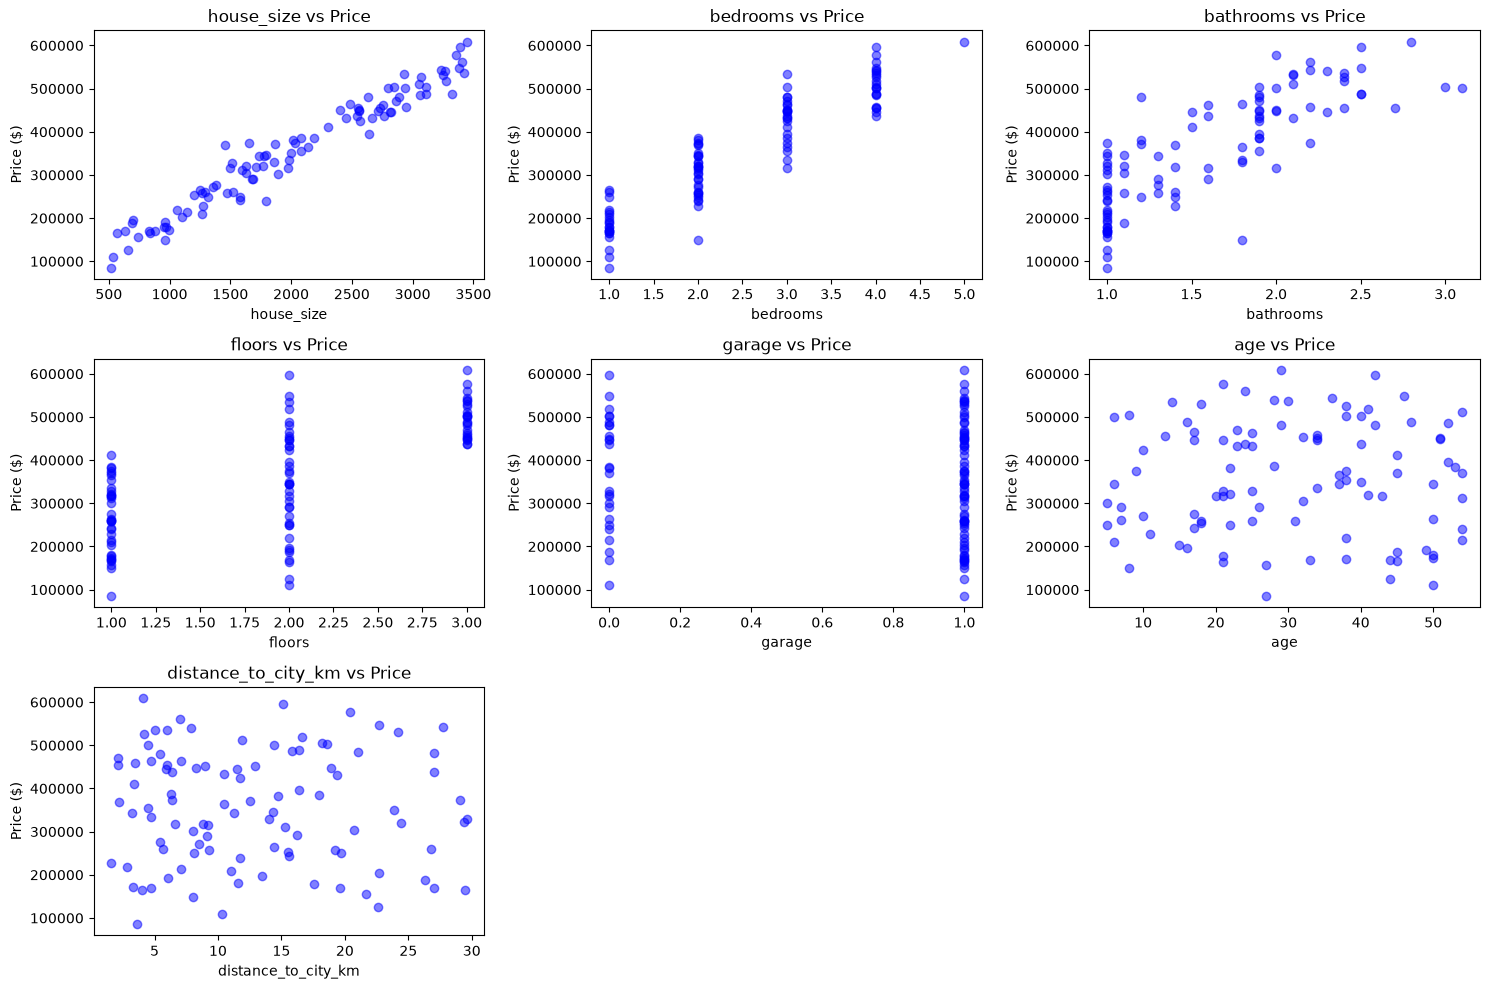

In [15]:

features = ["house_size", "bedrooms", "bathrooms", "floors", "garage", "age", "distance_to_city_km"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data["price"], alpha=0.5, color="blue")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price ($)")
    axes[i].set_title(f"{feature} vs Price")

# hide the 2 empty subplots (3x3 = 9 slots, we have 7 features)
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
def min_max_normalization(array : NDArray) -> NDArray:
        return (array - np.min(array)) / (np.max(array) - np.min(array))
def min_max_denormalization(array : NDArray , array_norm: NDArray) -> NDArray:
        return array_norm * (np.max(array) - np.min(array)) + np.min(array)
        # Y_predict_norm * (Y_raw.max() - Y_raw.min()) + Y_raw.min()



## Elimianting features that has no effect
* looking at the plots it is found out that the distance ,  no of garages and age has no effect on the price 
* take the 80% of data for training
 

In [36]:
features = ["house_size", "bedrooms", "bathrooms", "floors" ,"price"]
data = data[features]

actual_prices = data["price"][:80]

size_train = data["house_size"][:80]
bedrooms_train = data["bedrooms"][:80]
bathrooms_train = data["bathrooms"][:80]
floors_train = data["floors"][:80]

size_min, size_max         = size_train.min(), size_train.max()
bedrooms_min, bedrooms_max = bedrooms_train.min(), bedrooms_train.max()
bathrooms_min, bathrooms_max = bathrooms_train.min(), bathrooms_train.max()
floors_min, floors_max     = floors_train.min(), floors_train.max()

size_train = min_max_normalization(size_train)
bedrooms_train = min_max_normalization(bedrooms_train)
bathrooms_train = min_max_normalization(bathrooms_train)
floors_train = min_max_normalization(floors_train)

actual_prices = min_max_normalization(actual_prices)



In [40]:
w1 , w2 ,w3 ,w4 = 0 , 0, 0, 0
b=0
all_costs=[]
costs = 0
m = 80
while True:
    predited_prices = (w1 * size_train) + (w2 * bedrooms_train) + (w3 * bathrooms_train) + (w4 * floors_train) + b

    error = (1 / (2 * m)) * (np.sum((predited_prices - actual_prices) ** 2))

    j_w1 = (1 / m ) * (np.sum((predited_prices - actual_prices) * size_train))
    j_w2 = (1 / m ) * (np.sum((predited_prices - actual_prices) * bedrooms_train))
    j_w3 = (1 / m ) * (np.sum((predited_prices - actual_prices) * bathrooms_train))
    j_w4 = (1 / m ) * (np.sum((predited_prices - actual_prices) * floors_train))
    j_b = (1 / m) * (np.sum(predited_prices - actual_prices))
    print(error)
    w1 -= 1.068 * j_w1
    w2 -= 1.068 * j_w2
    w3 -= 1.068 * j_w3
    w4 -= 1.068 * j_w4
    b -= 1.068 * j_b
    if abs(costs - error) < 1e-10:
        break
    costs = error
    all_costs.append(error)
print(f"w1     = {w1:.4f}")
print(f"w2     = {w2:.4f}")
print(f"w3     = {w3:.4f}")
print(f"w4     = {w4:.4f}")
print(f"b     = {b:.4f}")
print(f"cost  = {costs}")
# w     = 0.8320
# b     = 0.0864
# cost  = 0.0011882965167950826



# 403696799.376182


0.1713620972906682
0.16942677927387312
0.16772923335045176
0.16620111987207886
0.1647953161450571
0.16347919665654911
0.1622300574796698
0.1610319987378268
0.15987379879819272
0.15874746321818745
0.15764723296316474
0.15656890538757906
0.1555093683484094
0.15446627968041865
0.1534378459199131
0.15242266888670086
0.15141963874464218
0.1504278589692148
0.14944659328172136
0.14847522776127278
0.14751324349120093
0.1465601965580568
0.14561570321763534
0.14467942872226391
0.14375107876800686
0.1428303928381963
0.14191713893755345
0.14101110936089079
0.14011211724362396
0.13921999371278587
0.13833458550695407
0.13745575296830115
0.13658336833451762
0.13571731427581876
0.13485748263480346
0.13400377333606667
0.1331560934392156
0.132314356313986
0.13147848092000017
0.130648391176681
0.1298240154111767
0.1290052858740158
0.12819213831373186
0.12738451160293707
0.12658234740936508
0.1257855899062691
0.12499418551730189
0.12420808269163285
0.12342723170559831
0.1226515844876496
0.1218810944637646

In [48]:

size_test = data["house_size"][80:]
bedrooms_test = data["bedrooms"][80:]
bathrooms_test = data["bathrooms"][80:]
floors_test = data["floors"][80:]
actual_prices = data["price"][:80]

size_test = min_max_normalization(size_test)
bedrooms_test = min_max_normalization(bedrooms_test)
bathrooms_test = min_max_normalization(bathrooms_test)
floors_test = min_max_normalization(floors_test)

# actual_prices_test = min_max_normalization(actual_prices)

actual_prices_test = data["price"][80:]


predictions =  (w1 * size_test) + (w2 * bedrooms_test) + (w3 * bathrooms_test) + (w4 * floors_test) + b


# denormalize output back to real prices
Y_predict = min_max_denormalization(actual_prices, predictions)

for actual_p , predict_p in zip(actual_prices , Y_predict):
    print(f"Actual : {actual_p} | Predicted : {predict_p}")
mae = np.mean(np.abs(actual_prices_test - Y_predict))
print(f"MAE = ${mae:,.0f}")

Actual : 271463 | Predicted : 192356.0767348705
Actual : 345732 | Predicted : 326673.55712172494
Actual : 321329 | Predicted : 286208.5579929168
Actual : 311899 | Predicted : 500110.6036203756
Actual : 364485 | Predicted : 568749.6678166105
Actual : 431645 | Predicted : 177895.28459695136
Actual : 149655 | Predicted : 260797.44344883607
Actual : 343689 | Predicted : 295665.6129940227
Actual : 169168 | Predicted : 244851.21073981083
Actual : 334988 | Predicted : 489997.3544694817
Actual : 480641 | Predicted : 242747.43496477857
Actual : 535903 | Predicted : 481823.2211954202
Actual : 169543 | Predicted : 180482.17737661017
Actual : 386646 | Predicted : 198136.7908961288
Actual : 209215 | Predicted : 311955.56881709234
Actual : 481375 | Predicted : 456208.42309838685
Actual : 381438 | Predicted : 131267.98924697863
Actual : 576817 | Predicted : 537700.2617245107
Actual : 534813 | Predicted : 341130.14869472996
Actual : 317395 | Predicted : 303481.58945252915
MAE = $24,869


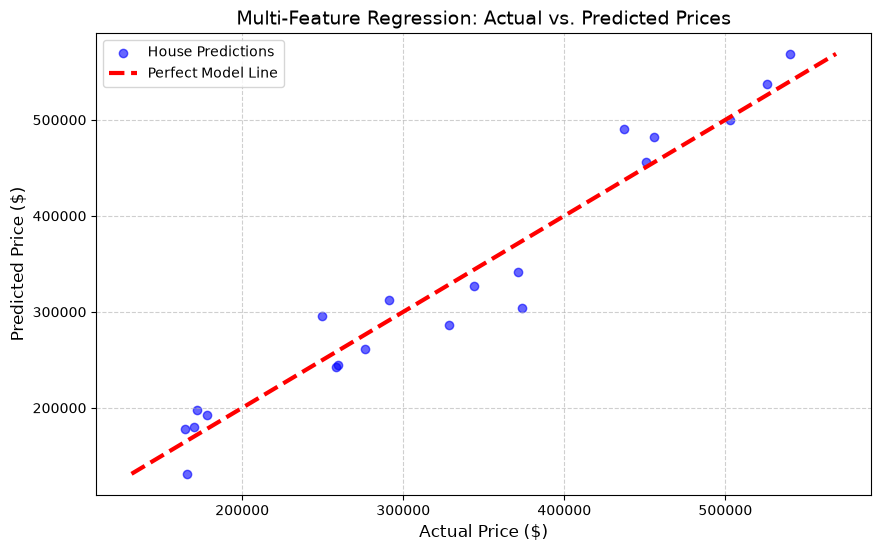

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure actual_prices_test and Y_predict are flattened 1D arrays
actuals = np.array(actual_prices_test).flatten()
predictions = np.array(Y_predict).flatten()

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(actuals, predictions, alpha=0.6, color="blue", label="House Predictions")

# 3. Draw the "Perfect Prediction" diagonal line
# We find the min and max values to know where to start and end the line
min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=3, linestyle="--", label="Perfect Model Line")

# 4. Add labels and title
plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.title("Multi-Feature Regression: Actual vs. Predicted Prices", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# 5. Show plot
plt.show()